In [2]:
import os
import pandas as pd

base_path = os.path.abspath("../..")
data_path = os.path.join(base_path, "data", "apartments_for_rent_classified_100K.csv")

df_raw = pd.read_csv(
    data_path,
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_raw.info()
df_raw.isnull().sum().sort_values(ascending=False).head(20)
df_raw.sample(5)
df_raw["price"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

count    99491.000000
mean      1527.057281
std        904.245882
min        100.000000
25%       1013.000000
50%       1350.000000
75%       1795.000000
max      52500.000000
Name: price, dtype: float64

In [3]:
df_raw["price"].quantile([0.01, 0.05, 0.95, 0.99])

0.01     545.0
0.05     699.0
0.95    2925.0
0.99    4250.0
Name: price, dtype: float64

In [4]:
df_raw[df_raw["price"]>10000]

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
537,5668636698,housing/rent/apartment,Two BR 1760 Avenida del Mundo Unit 508,This unit is located at 1760 Avenida del Mundo...,NaN,2.0,2.0,USD,No,Thumbnail,...,"$11,000",Monthly,1322,1760 Avenida Del Mundo Unit 508,Coronado,CA,32.6596,-117.1595,RentLingo,1577360129
3487,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,USD,No,Thumbnail,...,"$25,000",Monthly,8716,256 Las Entradas,Montecito,CA,34.4331,-119.6331,RentLingo,1577360419
3907,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,USD,No,Thumbnail,...,"$11,000",Monthly,11318,9908 Bentcross Dr,Potomac,MD,39.0287,-77.2409,RentLingo,1577360560
5222,5664581587,housing/rent/apartment,Six BR 3033 N Beverly Glen Cir,This unit is located at 3033 N Beverly Glen Ci...,NaN,4.0,6.0,USD,No,Thumbnail,...,"$14,950",Monthly,4044,3033 N Beverly Glen Circle,Los Angeles,CA,34.0372,-118.2972,RentLingo,1577015930
6574,5659901599,housing/rent/apartment,Four BR 864 Teakwood Rd,"This unit is located at 864 Teakwood Rd, Los A...","Dishwasher,Parking,Pool,Refrigerator",5.0,4.0,USD,No,Thumbnail,...,"$19,500",Monthly,5000,864 Teakwood Road,Los Angeles,CA,34.0372,-118.2972,RentLingo,1576666648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93975,5122325289,housing/rent/apartment,Convenient location Three BR 2.50 BA for rent....,"Square footage: 2591 sq. feet, unit number: 17...",Parking,2.5,3.0,USD,No,Yes,...,"$10,379",Monthly,2591,NaN,Nashville,TN,36.0960,-86.8262,RentDigs.com,1544275278
95244,5122012570,housing/rent/apartment,luxurious Four Seasons. Parking Available!,Amazing location. A wonderful opportunity to l...,Parking,5.0,4.0,USD,No,Yes,...,"$19,500",Monthly,4380,NaN,San Francisco,CA,37.7740,-122.4104,RentDigs.com,1544250657
95774,5121433095,housing/rent/apartment,Bedford - superb Apartment nearby fine dining,Enter private gates to a four plus acre TOTALL...,"AC,Cable or Satellite,Dishwasher,Fireplace,Gym...",6.0,5.0,USD,No,Yes,...,"$11,500",Monthly,8643,NaN,Bedford,NY,41.1852,-73.6409,RentDigs.com,1544202710
95926,5121048460,housing/rent/apartment,Two BR Apartment - In one of the most sought a...,Apartment 3R in the Chelsea Mercantile is the ...,"Doorman,Gym,Parking,Patio/Deck,Storage,Washer ...",2.0,2.0,USD,No,Yes,...,"$11,250",Monthly,2269,NaN,New York,NY,40.7247,-73.9545,RentDigs.com,1544174637


In [5]:
(df_raw["price"] == 0).sum()

0

In [6]:
df_raw[df_raw["price"] == 0].head(10)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time


In [7]:
import os
import pandas as pd
import numpy as np

# =========================
# 1. Load data
# =========================
base_path = os.path.abspath("../..")
data_path = os.path.join(base_path, "data", "apartments_for_rent_classified_100K.csv")

df = pd.read_csv(
    data_path,
    sep=";",
    encoding="latin1",
    low_memory=False
)

print("Original shape:", df.shape)

# =========================
# 2. Standardize missing values
# =========================
df = df.replace(["null", "NULL", "", " "], np.nan)

# =========================
# 3. Drop duplicates
# =========================
df = df.drop_duplicates()
df = df.drop_duplicates(subset=["id"])

# =========================
# 4. Standardize text fields
# =========================
df["price_type"] = df["price_type"].astype(str).str.strip().str.lower()
df["category"] = df["category"].astype(str).str.strip().str.lower()
df["state"] = df["state"].astype("string")
df["cityname"] = df["cityname"].astype("string")

# Keep apartment listings only
df = df[df["category"] == "housing/rent/apartment"]

# =========================
# 5. Convert numeric columns
# =========================
numeric_cols = ["price", "bathrooms", "bedrooms", "square_feet", "latitude", "longitude"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 6. Standardize price to monthly
# =========================
df = df[df["price_type"].isin(["monthly", "weekly"])]

df["price_monthly"] = np.where(
    df["price_type"] == "weekly",
    df["price"] * (52 / 12),
    df["price"]
)

# Drop missing target
df = df.dropna(subset=["price_monthly"])

# =========================
# 7. Remove unreasonable values
# =========================
df = df[(df["price_monthly"] > 0) & (df["price_monthly"] < 10000)]
df = df[(df["bathrooms"].isna()) | ((df["bathrooms"] > 0) & (df["bathrooms"] < 10))]
df = df[(df["bedrooms"].isna()) | ((df["bedrooms"] >= 0) & (df["bedrooms"] < 10))]
df = df[(df["square_feet"].isna()) | ((df["square_feet"] > 100) & (df["square_feet"] < 10000))]

# =========================
# 8. Clean location fields
# =========================
df["state"] = df["state"].fillna("Unknown").str.strip()
df["cityname"] = df["cityname"].fillna("Unknown").str.strip()

# Only lat/lon are required for spatial analysis
df = df.dropna(subset=["latitude", "longitude"])

df["lat"] = df["latitude"]
df["lon"] = df["longitude"]

# =========================
# 9. Clean text columns
# =========================
df["pets_allowed"] = df["pets_allowed"].fillna("No Info").str.strip().str.lower()
df["amenities_clean"] = df["amenities"].fillna("").str.lower()
df["has_photo"] = df["has_photo"].fillna("no").astype(str).str.strip().str.lower()

# =========================
# 10. Pet features
# =========================
df["pet_cat"] = df["pets_allowed"].str.contains("cat", regex=False).astype(int)
df["pet_dog"] = df["pets_allowed"].str.contains("dog", regex=False).astype(int)
df["pet_any"] = ((df["pet_cat"] == 1) | (df["pet_dog"] == 1)).astype(int)

# =========================
# 11. Amenity features
# =========================
key_amenities = ["parking", "pool", "gym", "dishwasher", "elevator", "washer", "dryer"]

for item in key_amenities:
    df[f"amenity_{item}"] = df["amenities_clean"].str.contains(item, regex=False).astype(int)

df["has_amenities"] = df["amenities"].notna().astype(int)

# =========================
# 12. Time conversion
# =========================
df["time"] = pd.to_datetime(df["time"], unit="s", errors="coerce")
df["month"] = df["time"].dt.month
df["year"] = df["time"].dt.year

# =========================
# 13. Log target for modeling
# =========================
df["log_price"] = np.log1p(df["price_monthly"])

# =========================
# 14. Final quick check
# =========================
print("Cleaned shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nPrice summary:")
print(df["price_monthly"].describe())

print("\nSample columns:")
print(df[[
    "price_monthly", "log_price", "bedrooms", "bathrooms", "square_feet",
    "state", "cityname", "lat", "lon", "pet_any"
] + [f"amenity_{a}" for a in key_amenities]].head())
df.shape
df.isnull().sum().sort_values(ascending=False).head(20)

Original shape: (99492, 22)
Cleaned shape: (99237, 40)

Missing values:
address               91308
amenities             16011
bedrooms                122
bathrooms                58
id                        0
amenity_pool              0
lon                       0
amenities_clean           0
pet_cat                   0
pet_dog                   0
pet_any                   0
amenity_parking           0
amenity_dishwasher        0
amenity_gym               0
price_monthly             0
amenity_elevator          0
amenity_washer            0
amenity_dryer             0
has_amenities             0
month                     0
dtype: int64

Price summary:
count    99237.000000
mean      1514.828434
std        758.314739
min        100.000000
25%       1012.000000
50%       1350.000000
75%       1795.000000
max       9975.000000
Name: price_monthly, dtype: float64

Sample columns:
   price_monthly  log_price  bedrooms  bathrooms  square_feet state  \
0         2195.0   7.694393       1.0  

address               91308
amenities             16011
bedrooms                122
bathrooms                58
id                        0
amenity_pool              0
lon                       0
amenities_clean           0
pet_cat                   0
pet_dog                   0
pet_any                   0
amenity_parking           0
amenity_dishwasher        0
amenity_gym               0
price_monthly             0
amenity_elevator          0
amenity_washer            0
amenity_dryer             0
has_amenities             0
month                     0
dtype: int64

In [8]:
print("df_raw shape:", df_raw.shape)
print("df shape:", df.shape)
df_raw["price_type"].value_counts()
print(df_raw.shape[0])
print(df_raw["id"].nunique())
print(df_raw["id"].duplicated().sum())
df_raw["body"].astype(str).str.contains("\n", regex=False).sum()
rows_with_newline = df_raw[df_raw["body"].astype(str).str.contains("\n", regex=False)]
rows_with_newline[["id", "body"]].head(3)
print("rows:", df_raw.shape[0])
print("unique ids:", df_raw["id"].nunique())
print("duplicate ids:", df_raw["id"].duplicated().sum())
print("body contains newline:", df_raw["body"].astype(str).str.contains("\n", regex=False).sum())

df_raw shape: (99492, 22)
df shape: (99237, 40)
99492
99408
84
rows: 99492
unique ids: 99408
duplicate ids: 84
body contains newline: 7


In [9]:
for col in ["currency", "fee", "price_type", "source", "has_photo", "state"]:
    print("\n", col)
    print(df_raw[col].value_counts(dropna=False).head(10))


 currency
currency
USD    99492
Name: count, dtype: int64

 fee
fee
No     99291
Yes      201
Name: count, dtype: int64

 price_type
price_type
Monthly           99488
Weekly                3
Monthly|Weekly        1
Name: count, dtype: int64

 source
source
RentDigs.com        90912
RentLingo            6924
ListedBuy             571
GoSection8            437
RealRentals           268
tenantcloud           124
BostonApartments       94
RENTCafé               41
Listanza               29
SpreadMyAd             22
Name: count, dtype: int64

 has_photo
has_photo
Yes          55974
Thumbnail    34303
No            9215
Name: count, dtype: int64

 state
state
TX    11257
CA    10311
VA     8284
NC     6300
CO     6290
FL     5775
MD     5280
MA     5030
OH     4905
GA     4752
Name: count, dtype: int64


In [10]:
missing = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(10))

address         92.016444
pets_allowed    60.732521
amenities       16.125920
state            0.303542
cityname         0.303542
bedrooms         0.124633
bathrooms        0.063322
longitude        0.025128
latitude         0.025128
price            0.001005
dtype: float64


In [11]:
print(df_raw["id"].nunique())
print(df_raw.shape[0])

99408
99492


In [12]:
df_raw[["title", "body", "amenities", "pets_allowed"]].sample(5)

,title,body,amenities,pets_allowed
20906,Two BR Apartment - Live the lifestyle you. Car...,Square footage: 1299 square ft A brand new lux...,Parking,NaN
35984,Glen Burnie - superb Apartment nearby fine din...,This garden community is located in Glen Burni...,Parking,NaN
55211,One BR Apartment - When you find a to live as ...,"Square footage: 730 square feet, unit number: ...",Gym,NaN
55337,Two BR Apartment - Spacious 2b/Two BA with out...,"Polished concrete floors, brick walls, large w...","Cable or Satellite,Internet Access,Patio/Deck,...",NaN
32105,The Best of the Best in the City of Stoughton!...,2018! first HOUSE SAT 8/18 10AM - 12PM AND SUN...,"AC,Parking,Patio/Deck,Storage",NaN


In [13]:

df_raw["amenities"].isnull().mean()


0.16125919671933422

In [14]:
df_raw["amenities"].dropna().str.split(",").apply(len).describe()

count    83448.000000
mean         4.367498
std          3.151179
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         18.000000
Name: amenities, dtype: float64

               price_monthly  square_feet  bedrooms  bathrooms
price_monthly       1.000000     0.383893  0.241117   0.321004
square_feet         0.383893     1.000000  0.710257   0.715240
bedrooms            0.241117     0.710257  1.000000   0.678410
bathrooms           0.321004     0.715240  0.678410   1.000000


<Axes: xlabel='bedrooms', ylabel='price_monthly'>

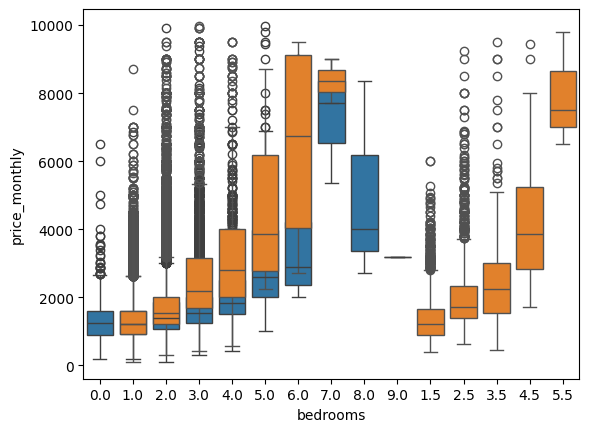

In [15]:
import seaborn as sns

corr = df[["price_monthly", "square_feet", "bedrooms", "bathrooms"]].corr()
print(corr)
sns.boxplot(x=df["bedrooms"], y=df["price_monthly"])
sns.boxplot(x=df["bathrooms"], y=df["price_monthly"])

In [16]:
for col in df_raw.columns:
    print("\n" + "="*50)
    print("Column:", col)
    print("Dtype:", df_raw[col].dtype)
    print("Missing:", df_raw[col].isnull().sum(), 
          f"({df_raw[col].isnull().mean()*100:.2f}%)")
    print("Unique:", df_raw[col].nunique(dropna=False))
    
    if df_raw[col].dtype == "object":
        print(df_raw[col].value_counts(dropna=False).head(10))
    else:
        print(df_raw[col].describe())


Column: id
Dtype: int64
Missing: 0 (0.00%)
Unique: 99408
count    9.949200e+04
mean     5.358321e+09
std      1.847404e+08
min      5.121046e+09
25%      5.197950e+09
50%      5.508673e+09
75%      5.509007e+09
max      5.669439e+09
Name: id, dtype: float64

Column: category
Dtype: object
Missing: 0 (0.00%)
Unique: 7
category
housing/rent/apartment            99431
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64

Column: title
Dtype: object
Missing: 0 (0.00%)
Unique: 58503
title
Apartment in great location                            1064
Apartment in prime location                            1028
Apartment in quiet area, spacious with big kitchen     1023
Super Cute! Apartment for Rent!                        1018
This Apartment is a must see!                          10

In [17]:
print("Rows before:", df_raw.shape[0])
print("Rows after:", df.shape[0])
print("Columns before:", df_raw.shape[1])
print("Columns after:", df.shape[1])
print("\nMissing BEFORE:")
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing AFTER:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nPrice BEFORE:")
print(df_raw["price"].describe())

print("\nPrice AFTER:")
print(df["price_monthly"].describe())
print(df_raw["category"].value_counts().head())
print(df["category"].value_counts().head())

Rows before: 99492
Rows after: 99237
Columns before: 22
Columns after: 40

Missing BEFORE:
address         91549
pets_allowed    60424
amenities       16044
state             302
cityname          302
bedrooms          124
bathrooms          63
longitude          25
latitude           25
price               1
dtype: int64

Missing AFTER:
address            91308
amenities          16011
bedrooms             122
bathrooms             58
id                     0
amenity_pool           0
lon                    0
amenities_clean        0
pet_cat                0
pet_dog                0
dtype: int64

Price BEFORE:
count    99491.000000
mean      1527.057281
std        904.245882
min        100.000000
25%       1013.000000
50%       1350.000000
75%       1795.000000
max      52500.000000
Name: price, dtype: float64

Price AFTER:
count    99237.000000
mean      1514.828434
std        758.314739
min        100.000000
25%       1012.000000
50%       1350.000000
75%       1795.000000
max       

## Conduct EDA on the current data.

In [18]:
# Overall understanding of data
print(df.shape)
print(df.info())

# miss rate
missing = df.isnull().mean().sort_values(ascending=False)
print(missing.head(10))

# View the sample
df.sample(5)

(99237, 40)
<class 'pandas.core.frame.DataFrame'>
Index: 99237 entries, 0 to 99491
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  99237 non-null  int64         
 1   category            99237 non-null  object        
 2   title               99237 non-null  object        
 3   body                99237 non-null  object        
 4   amenities           83226 non-null  object        
 5   bathrooms           99179 non-null  float64       
 6   bedrooms            99115 non-null  float64       
 7   currency            99237 non-null  object        
 8   fee                 99237 non-null  object        
 9   has_photo           99237 non-null  object        
 10  pets_allowed        99237 non-null  object        
 11  price               99237 non-null  float64       
 12  price_display       99237 non-null  object        
 13  price_type          99237 non-null  obj

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,amenity_pool,amenity_gym,amenity_dishwasher,amenity_elevator,amenity_washer,amenity_dryer,has_amenities,month,year,log_price
59925,5198377486,housing/rent/apartment,"Move-in condition, Two BR Two BA","Square footage: 1093 sq-ft, unit number: 3204....","Parking,Storage",2.0,2.0,USD,No,thumbnail,...,0,0,0,0,0,0,1,2,2019,7.202661
15425,5509179165,housing/rent/apartment,Cute studio with a one car garage and backyard!,Convenient wakable and bikeable location with ...,"Parking,Wood Floors",1.0,0.0,USD,No,yes,...,0,0,0,0,0,0,1,9,2019,7.208600
96336,5122114872,housing/rent/apartment,Convenient location Two BR One BA for rent,"Located in Speedway, IN, 1 of the premier neig...","AC,Basketball,Dishwasher,Pool",1.0,2.0,USD,No,yes,...,1,0,1,0,1,0,1,12,2018,6.484635
61356,5198142452,housing/rent/apartment,Outstanding Opportunity To Live At The Omaha C...,"Square footage: 650 square feet, unit number: ...","Basketball,Gym,Internet Access,Patio/Deck,Pool...",1.0,1.0,USD,No,thumbnail,...,1,1,0,0,1,1,1,2,2019,6.685861
77408,5198185564,housing/rent/apartment,Apartment in prime location. Single Car Garage!,"Square footage: 1450 square feet, unit number:...","Cable or Satellite,Clubhouse,Dishwasher,Gated,...",2.0,2.0,USD,No,thumbnail,...,1,1,1,0,1,0,1,2,2019,7.484930


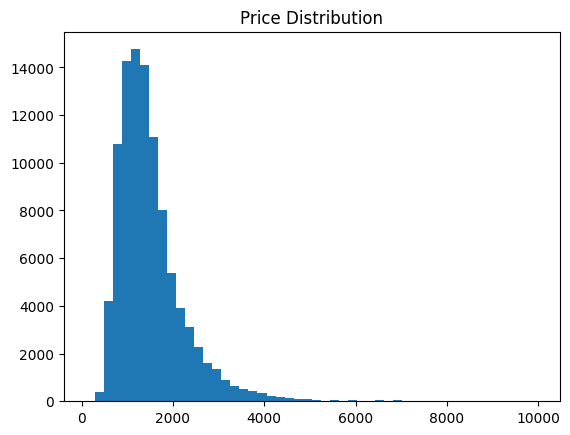

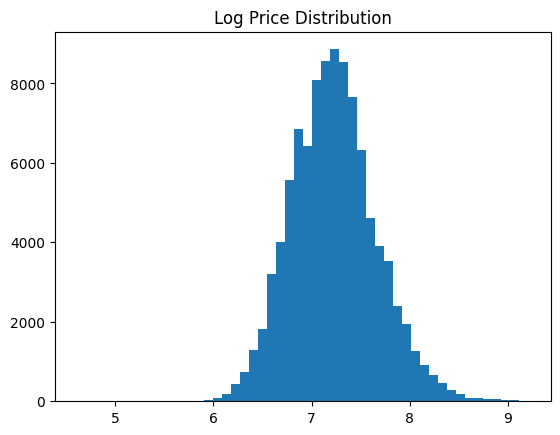

count    99237.000000
mean      1514.828434
std        758.314739
min        100.000000
25%       1012.000000
50%       1350.000000
75%       1795.000000
max       9975.000000
Name: price_monthly, dtype: float64


In [19]:
#Target(price) analysis
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(df["price_monthly"], bins=50)
plt.title("Price Distribution")
plt.show()

plt.figure()
plt.hist(df["log_price"], bins=50)
plt.title("Log Price Distribution")
plt.show()

print(df["price_monthly"].describe())

In [20]:
from scipy.stats import skew

print("Original price skew:", skew(df["price_monthly"]))
print("Log price skew:", skew(df["log_price"]))

Original price skew: 2.4349124022139668
Log price skew: 0.31718162554178203


In [21]:
corr_raw = df[["price_monthly", "square_feet", "bedrooms", "bathrooms"]].corr()
corr_log = df[["log_price", "square_feet", "bedrooms", "bathrooms"]].corr()

print("Raw correlation:\n", corr_raw)
print("\nLog correlation:\n", corr_log)

Raw correlation:
                price_monthly  square_feet  bedrooms  bathrooms
price_monthly       1.000000     0.383893  0.241117   0.321004
square_feet         0.383893     1.000000  0.710257   0.715240
bedrooms            0.241117     0.710257  1.000000   0.678410
bathrooms           0.321004     0.715240  0.678410   1.000000

Log correlation:
              log_price  square_feet  bedrooms  bathrooms
log_price     1.000000     0.383040  0.244513   0.329641
square_feet   0.383040     1.000000  0.710257   0.715240
bedrooms      0.244513     0.710257  1.000000   0.678410
bathrooms     0.329641     0.715240  0.678410   1.000000


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1️⃣ 处理缺失值
df_model = df[["square_feet", "bedrooms", "bathrooms", "price_monthly", "log_price"]].dropna()

# 2️⃣ 定义X和y
X = df_model[["square_feet", "bedrooms", "bathrooms"]]
y1 = df_model["price_monthly"]
y2 = df_model["log_price"]

# 3️⃣ 划分数据
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

# 4️⃣ 模型（raw price）
model1 = LinearRegression()
model1.fit(X_train, y1_train)
pred1 = model1.predict(X_test)

# 5️⃣ 模型（log price）
model2 = LinearRegression()
model2.fit(X_train, y2_train)
pred2 = model2.predict(X_test)

# 6️⃣ 输出结果
print("MAE (raw price):", mean_absolute_error(y1_test, pred1))
print("MAE (log price):", mean_absolute_error(y2_test, pred2))

MAE (raw price): 491.18478510091273
MAE (log price): 0.31391966613916666


## Analysis of Numerical variables

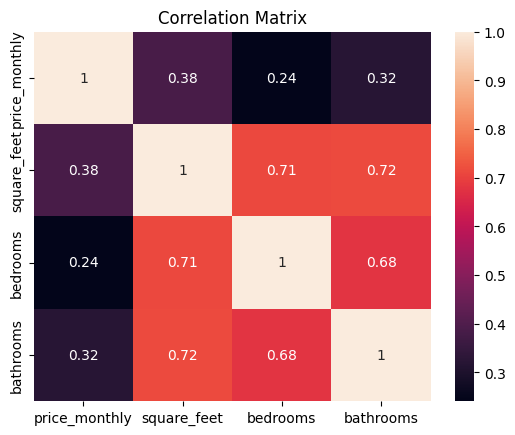

In [23]:
# dependency
import seaborn as sns

corr = df[["price_monthly", "square_feet", "bedrooms", "bathrooms"]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()



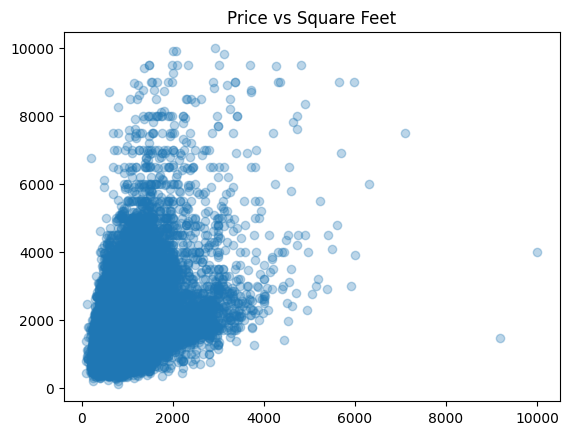

In [24]:
#relational graph
plt.figure()
plt.scatter(df["square_feet"], df["price_monthly"], alpha=0.3)
plt.title("Price vs Square Feet")
plt.show()

The correlation matrix shows that structural features such as square footage, number of bedrooms, and number of bathrooms are moderately correlated with price, with square footage having the strongest relationship (0.38). This indicates that no single feature fully explains price variation, and multiple factors must be considered together.

Additionally, there is strong correlation among the structural features themselves (e.g., square footage and bathrooms: 0.72), indicating multicollinearity. This suggests that regularized models such as Ridge regression may be more appropriate than standard linear regression.

The scatter plot between price and square footage further reveals a positive but non-linear relationship. Price increases with size, but at a decreasing rate, indicating diminishing returns. Furthermore, the spread of data points increases with size, suggesting heteroskedasticity. These patterns motivate the use of log transformation and more flexible modeling approaches.
相关性矩阵显示，房屋结构变量（面积、卧室数、卫生间数）与价格存在中等程度的相关性，其中面积的相关性最高（0.38）。这说明单一变量无法完全解释价格变化，需要多个变量共同建模。

同时，这些结构变量之间存在较强相关性（如面积与卫生间相关性为0.72），表明存在多重共线性问题，因此相比普通线性回归，Ridge等正则化模型更合适。

从价格与面积的散点图可以看出，两者呈正相关，但关系并非线性，而是存在边际递减效应。此外，随着面积增加，数据的离散程度也在增加，表明存在异方差问题。这些现象支持使用对数变换以及更灵活的模型。

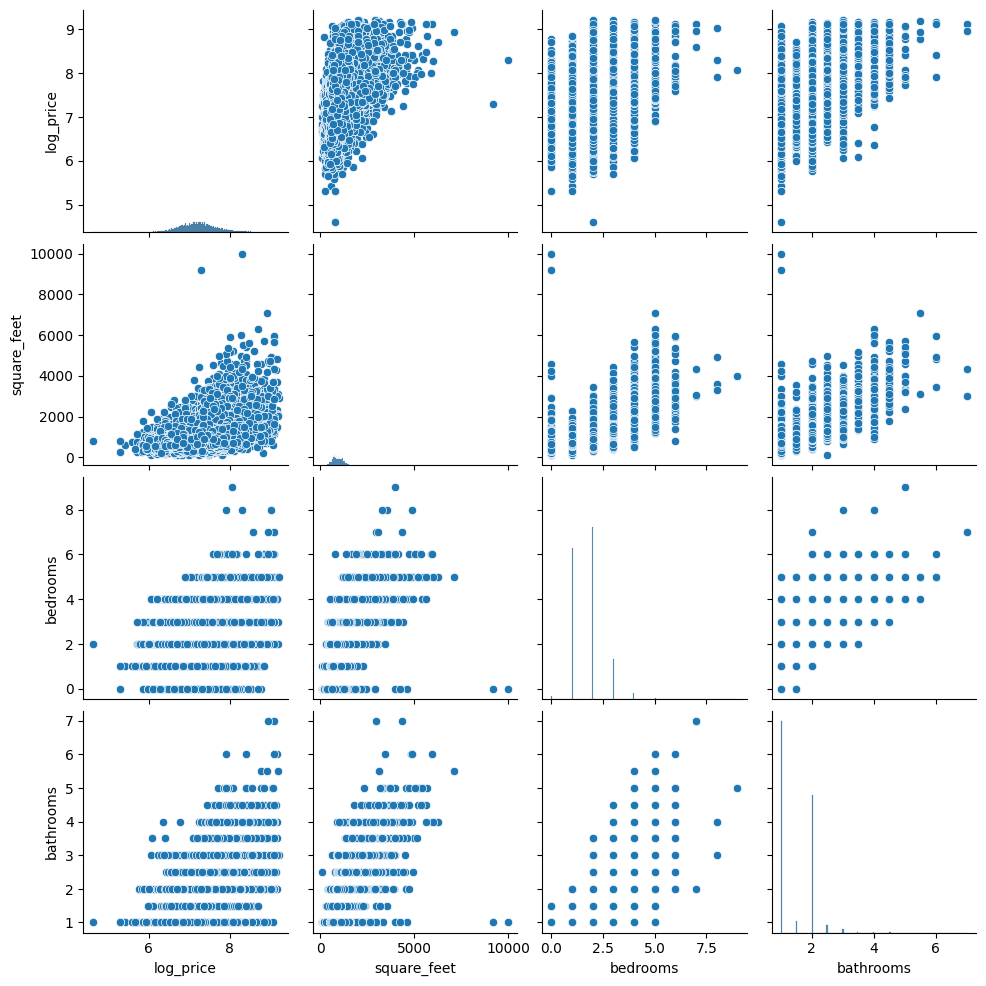

In [25]:
sns.pairplot(df[["log_price", "square_feet", "bedrooms", "bathrooms"]])

The pairplot provides a more detailed view of the relationships between variables. The relationship between log-transformed price and square footage shows a clear positive trend, but with a non-linear pattern and increasing variance, indicating heteroskedasticity.

For discrete variables such as bedrooms and bathrooms, the relationship with price appears in grouped vertical patterns, suggesting that these features influence price in a stepwise manner rather than continuously.

Additionally, strong relationships are observed among structural features (e.g., square footage and number of bedrooms), confirming the presence of multicollinearity. These observations support the use of regularized models and potentially non-linear modeling approaches.
pairplot展示了变量之间更细致的关系。log价格与房屋面积之间呈现明显正相关，但关系并非线性，同时随着面积增加，数据离散程度也在增加，表明存在异方差问题。

对于卧室数和卫生间数这类离散变量，其与价格的关系呈现出分组结构，而非连续变化，说明这些变量对价格的影响具有“阶梯式”特征。

同时，结构变量之间（如面积与卧室数）存在明显相关性，进一步验证了多重共线性问题。这些发现支持采用正则化模型以及更灵活的非线性建模方法。

所以现在的这一部分显示卧室厕所和面积是正相关的关系，它们对价格的影响力占30-40%左右，如果用价格和面积生成关系图可以发现它们大部分都集中在0-4k和0-6k之间有一些outline

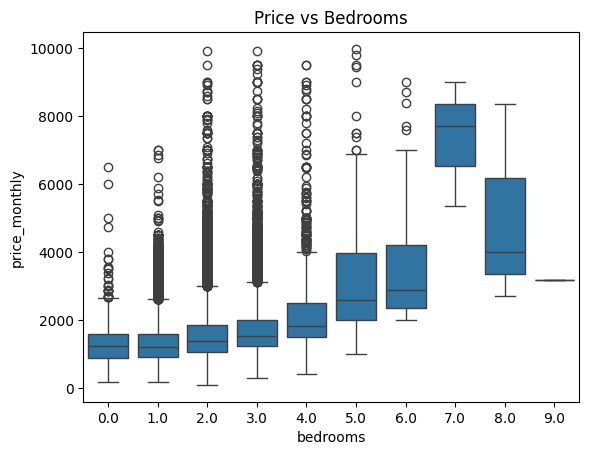

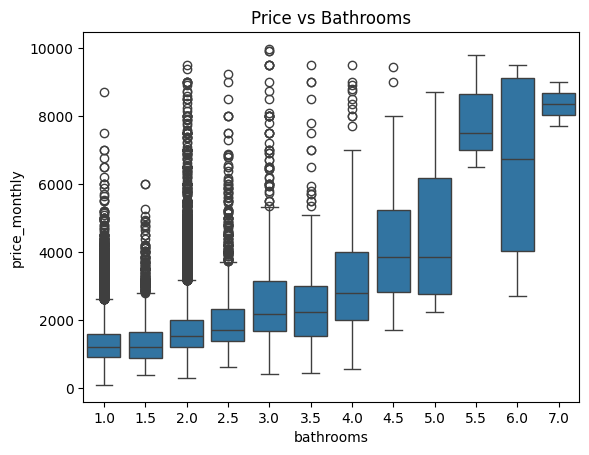

In [26]:
# Categorical numerical variable
plt.figure()
sns.boxplot(x=df["bedrooms"], y=df["price_monthly"])
plt.title("Price vs Bedrooms")
plt.show()

plt.figure()
sns.boxplot(x=df["bathrooms"], y=df["price_monthly"])
plt.title("Price vs Bathrooms")
plt.show()

Bedrooms and bathrooms have a clear impact on price, but they cannot fully explain price variation due to large dispersion, indicating the importance of additional features such as location and amenities.

Log transformation makes the price distribution more stable and closer to symmetric, making it more suitable for modeling.

Structural features such as square footage, bedrooms, and bathrooms show a positive relationship with price, but the relationship is not linear. Instead, it becomes more dispersed for larger properties, indicating heteroskedasticity and possible market segmentation.

In addition, large price variation exists within the same number of bedrooms or bathrooms, suggesting that structural features alone are insufficient to explain price, and other factors such as location and amenities play an important role.

### Price Distribution

The original price is right-skewed with extreme high values.  
After log transformation, the distribution becomes more symmetric and suitable for modeling.

## Analysis of categorical variables

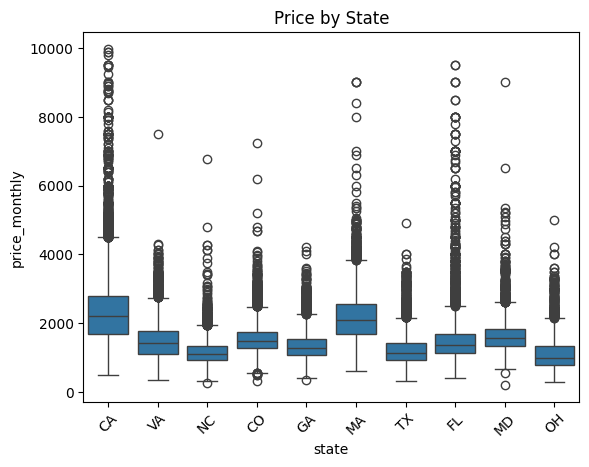

In [27]:
# state
top_states = df["state"].value_counts().head(10).index

plt.figure()
sns.boxplot(x=df[df["state"].isin(top_states)]["state"],
            y=df[df["state"].isin(top_states)]["price_monthly"])
plt.xticks(rotation=45)
plt.title("Price by State")
plt.show()

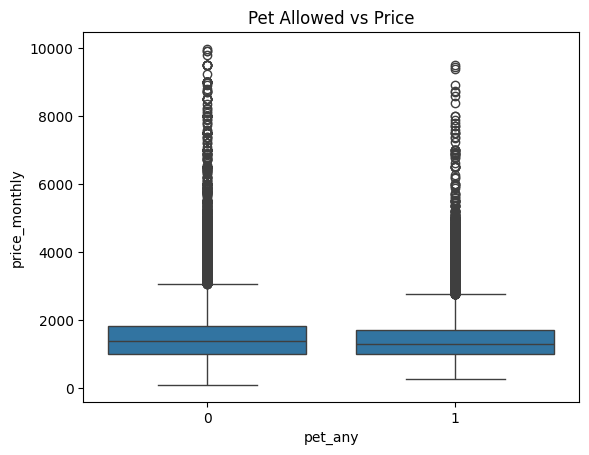

In [28]:
#pets
sns.boxplot(x=df["pet_any"], y=df["price_monthly"])
plt.title("Pet Allowed vs Price")
plt.show()

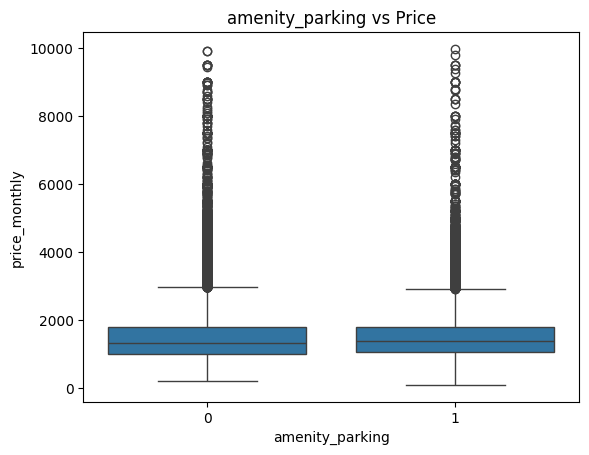

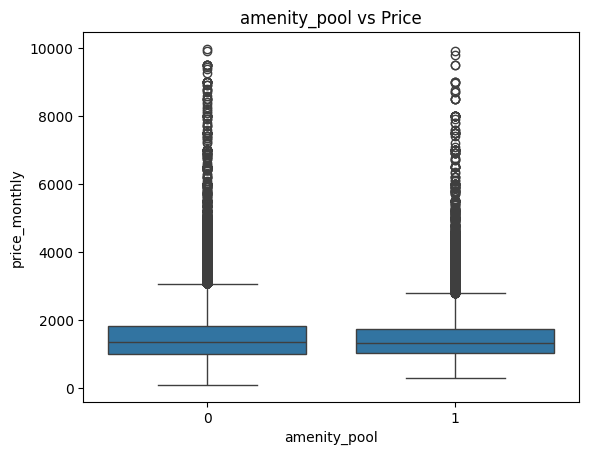

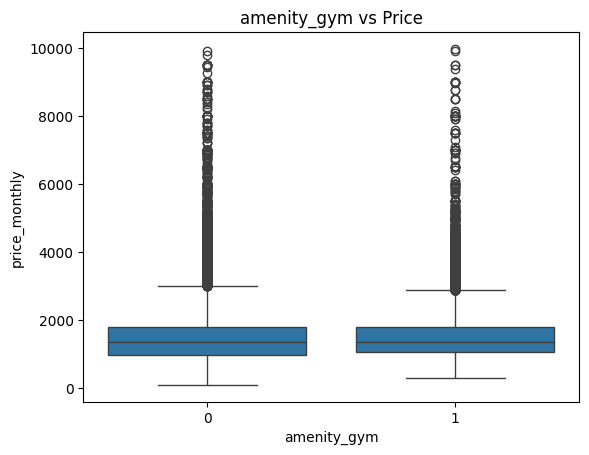

In [29]:
#amenities
for col in ["amenity_parking", "amenity_pool", "amenity_gym"]:
    sns.boxplot(x=df[col], y=df["price_monthly"])
    plt.title(f"{col} vs Price")
    plt.show()

The analysis of categorical variables shows that location (state) has a significant impact on rental prices, while features such as pet policy and amenities have relatively weak effects. However, these weaker effects may be due to the influence of dominant factors like location and property size, which mask their true contribution. Therefore, further conditional analysis is required.

The EDA results indicate that location variables such as state have a dominant effect on rental prices, while amenities and pet policies show relatively weaker influence. Therefore, in the baseline model, we prioritize structural and location-related features. However, amenities and pet-related variables are retained for further analysis, as they may provide additional explanatory power when combined with other variables.

## Price VS Geographical

In [ ]:
#Preparing the Database Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copy the data to avoid contaminating the original table.
df_eda = df.copy()

# Only keep the columns needed for analysis
cols_needed = ["price_monthly", "state", "cityname", "latitude", "longitude"]
df_eda = df_eda[cols_needed].copy()

# Drop rows with missing values in key columns
df_eda = df_eda.dropna(subset=["price_monthly", "state", "latitude", "longitude"])

# If the city name is missing, you can fill in "Unknown".
if "cityname" in df_eda.columns:
    df_eda["cityname"] = df_eda["cityname"].fillna("Unknown")

# Take the logarithm of the price.
df_eda["log_price"] = np.log1p(df_eda["price_monthly"])

print(df_eda.shape)
df_eda.head()

(99237, 6)


,price_monthly,state,cityname,latitude,longitude,log_price
0,2195.0,CA,Redondo Beach,33.8520,-118.3759,7.694393
1,1250.0,VA,Newport News,37.0867,-76.4941,7.131699
2,1395.0,NC,Raleigh,35.8230,-78.6438,7.241366
3,1600.0,CA,Vacaville,38.3622,-121.9712,7.378384
4,975.0,NM,Albuquerque,35.1038,-106.6110,6.883463


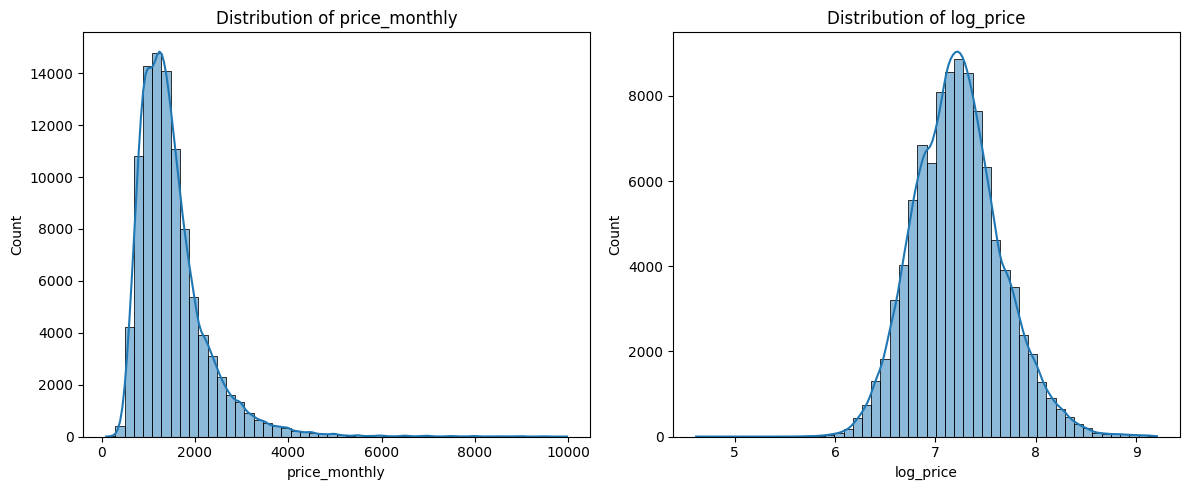

In [33]:
#  distribution of price and log_price
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_eda["price_monthly"], bins=50, kde=True)
plt.title("Distribution of price_monthly")

plt.subplot(1, 2, 2)
sns.histplot(df_eda["log_price"], bins=50, kde=True)
plt.title("Distribution of log_price")

plt.tight_layout()
plt.show()

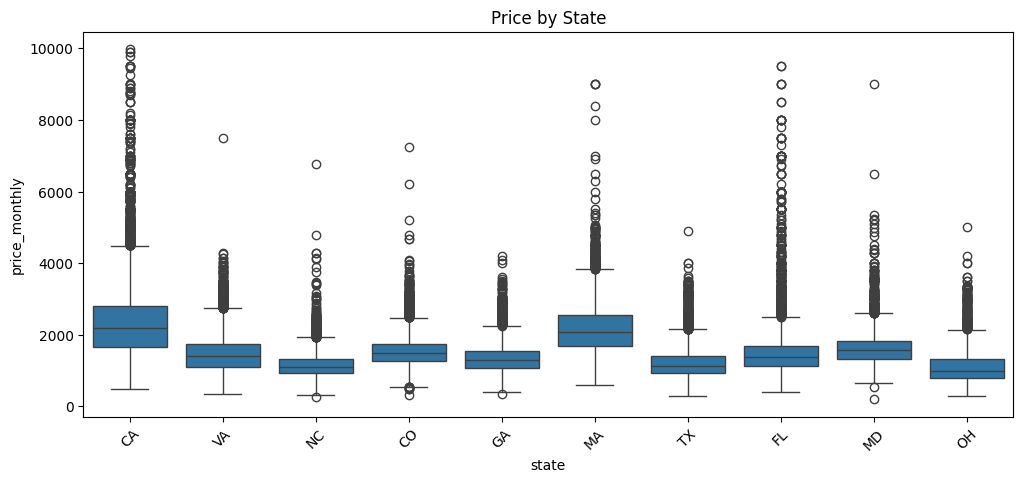

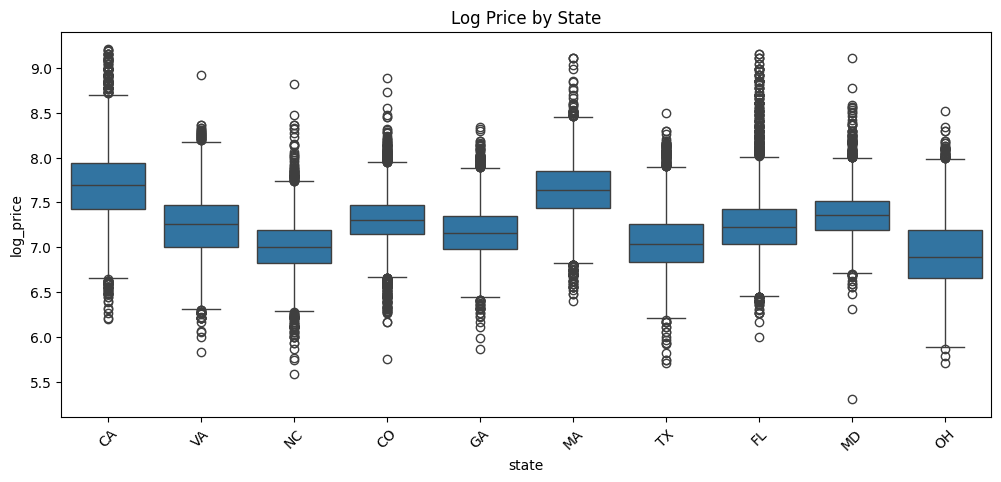

In [34]:
# State and price/log price
# top 10 states with the largest sample size
top_states = df_eda["state"].value_counts().head(10).index
df_state = df_eda[df_eda["state"].isin(top_states)].copy()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_state, x="state", y="price_monthly")
plt.xticks(rotation=45)
plt.title("Price by State")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_state, x="state", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by State")
plt.show()

In [ ]:
#Compare the central position
state_summary = (
    df_eda.groupby("state")
    .agg(
        count=("price_monthly", "size"),
        median_price=("price_monthly", "median"),
        mean_price=("price_monthly", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values("count", ascending=False)
)

state_summary.head(15)

,count,median_price,mean_price,median_log_price
state,,,,
TX,11248,1140.0,1217.572546,7.039660
CA,10243,2195.0,2378.000586,7.694393
VA,8276,1411.0,1485.618052,7.252762
NC,6293,1099.0,1154.039568,7.003065
CO,6276,1479.0,1549.970363,7.299797
FL,5759,1370.0,1550.501823,7.223296
MD,5233,1575.0,1643.114657,7.362645
MA,5023,2080.0,2192.226757,7.640604
OH,4898,979.0,1110.110453,6.887553


### Price by State

Prices vary significantly across states, indicating that location plays an important role.  
However, large variation still exists within each state.v

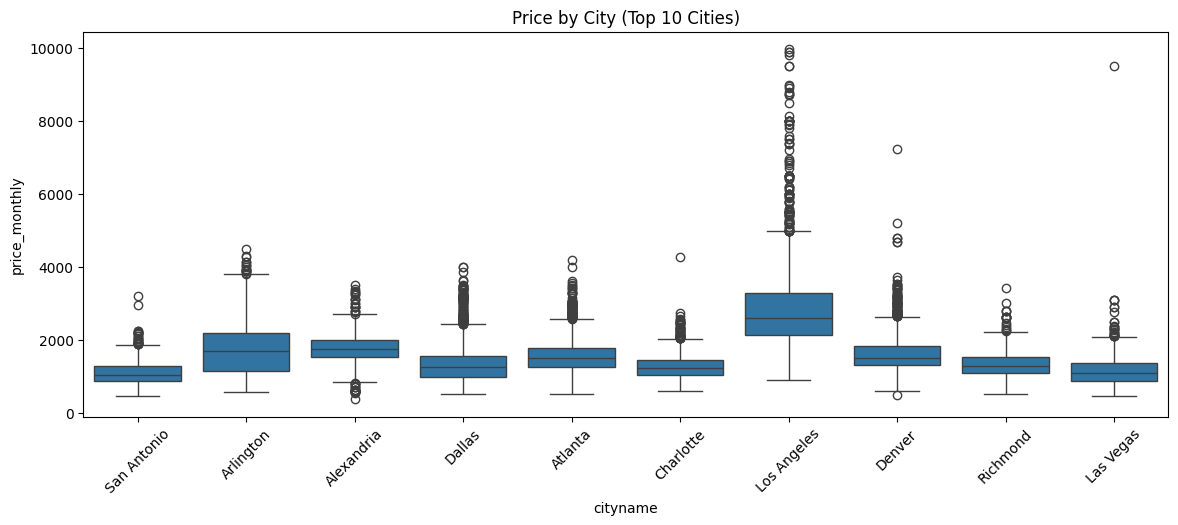

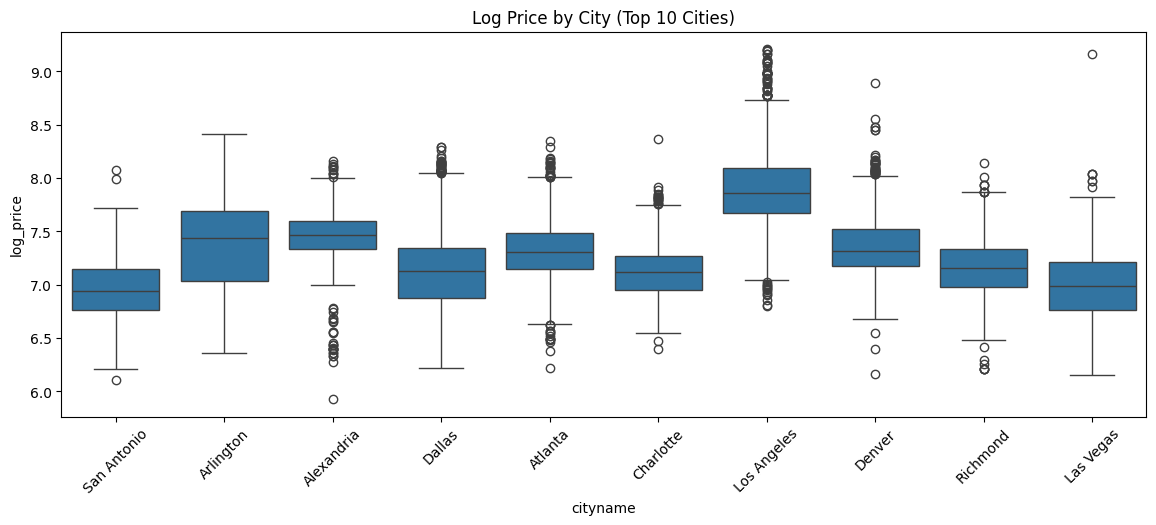

In [36]:
# City and Price/log price
top_cities = df_eda["cityname"].value_counts().head(10).index
df_city = df_eda[df_eda["cityname"].isin(top_cities)].copy()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_city, x="cityname", y="price_monthly")
plt.xticks(rotation=45)
plt.title("Price by City (Top 10 Cities)")
plt.show()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_city, x="cityname", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by City (Top 10 Cities)")
plt.show()

In [37]:
city_summary = (
    df_eda.groupby("cityname")
    .agg(
        count=("price_monthly", "size"),
        median_price=("price_monthly", "median"),
        mean_price=("price_monthly", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values("count", ascending=False)
)

city_summary.head(15)

,count,median_price,mean_price,median_log_price
cityname,,,,
Dallas,2856,1247.0,1336.984594,7.129298
Denver,2749,1499.0,1617.913423,7.313220
Los Angeles,2402,2600.0,2833.067860,7.863651
Las Vegas,1846,1080.5,1132.684182,6.986104
Arlington,1577,1700.0,1754.163602,7.438972
Atlanta,1504,1495.0,1598.846410,7.310550
Charlotte,1122,1229.0,1287.259358,7.114769
Richmond,914,1280.0,1312.852298,7.155396
Alexandria,914,1745.0,1781.623632,7.465083


### Price by City

City-level differences are more pronounced than state-level differences.  
This suggests that finer geographic information better explains price variation.

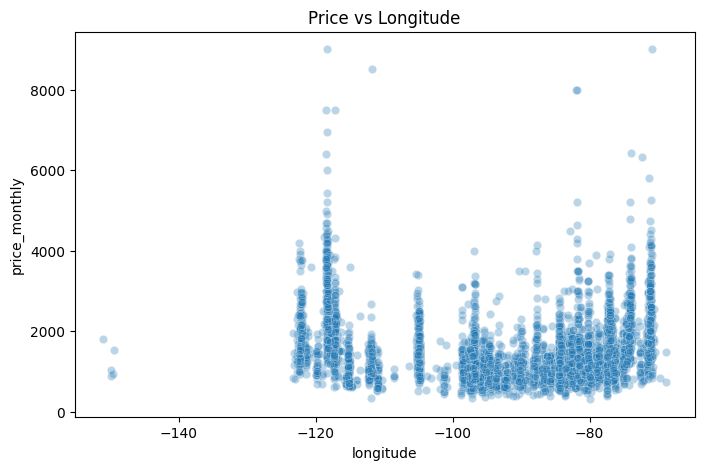

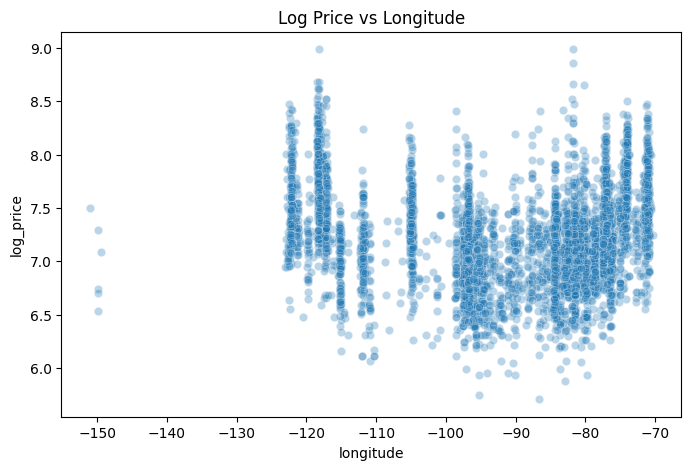

In [38]:
# Longitude vs. price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="longitude", y="price_monthly", alpha=0.3)
plt.title("Price vs Longitude")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="longitude", y="log_price", alpha=0.3)
plt.title("Log Price vs Longitude")
plt.show()

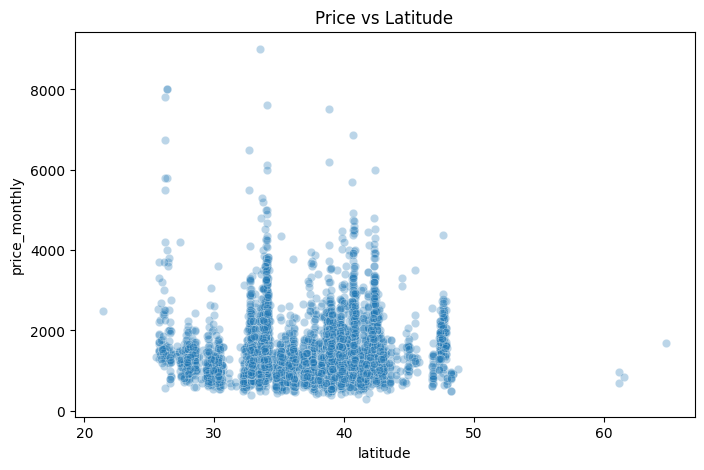

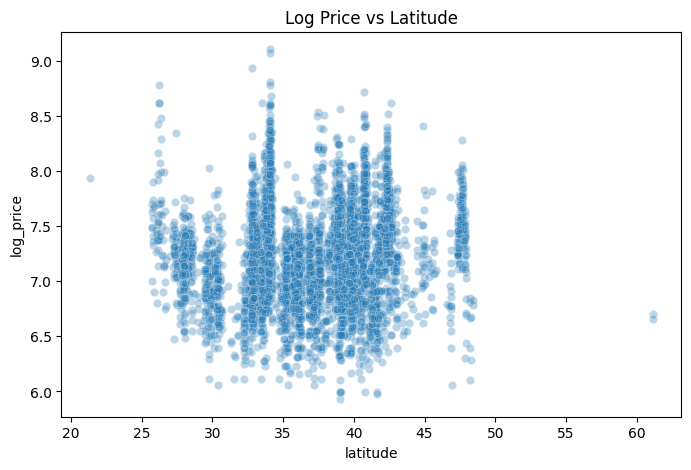

In [39]:
# Latitude vs. Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="latitude", y="price_monthly", alpha=0.3)
plt.title("Price vs Latitude")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="latitude", y="log_price", alpha=0.3)
plt.title("Log Price vs Latitude")
plt.show()

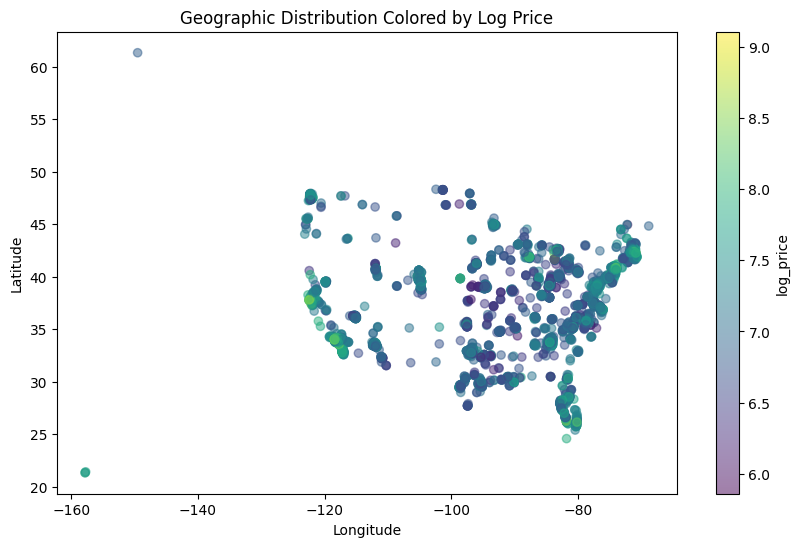

In [ ]:
# Two-dimensional scatter plot of geographical locations, colored by price
sample_geo = df_eda.sample(min(5000, len(df_eda)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_geo["longitude"], sample_geo["latitude"], c=sample_geo["log_price"], alpha=0.5)
plt.colorbar(label="log_price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution Colored by Log Price")
plt.show()

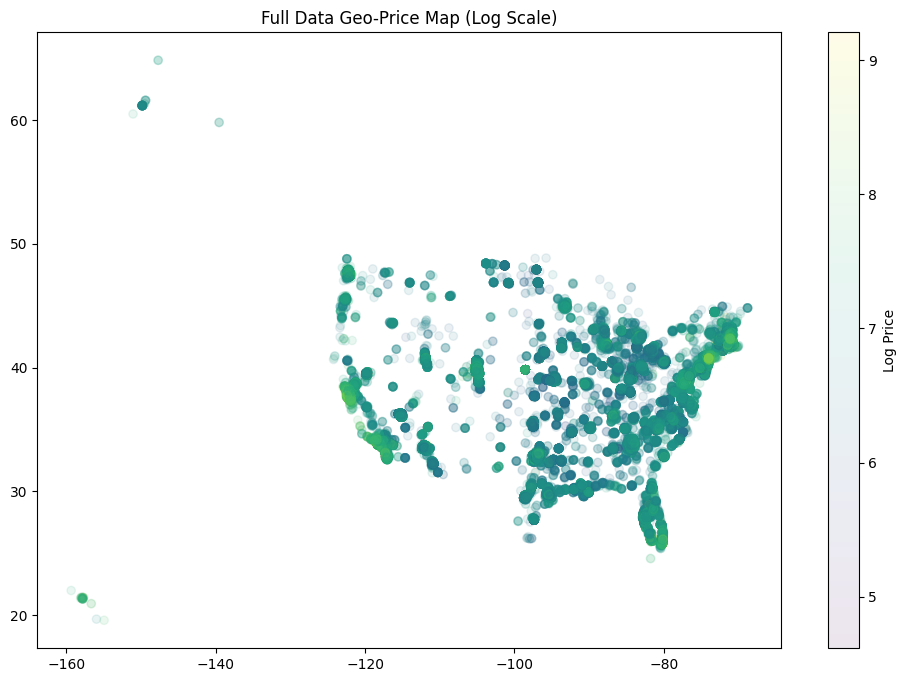

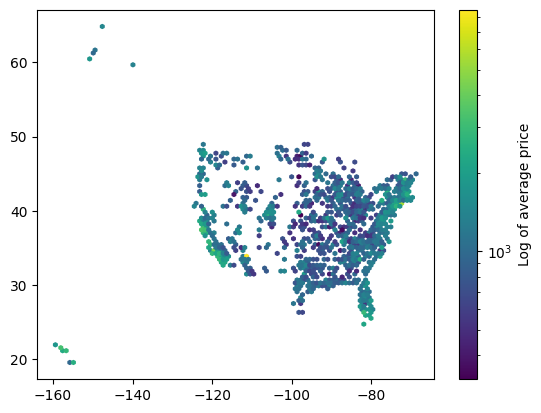

In [44]:
plt.figure(figsize=(12, 8))

# 1. 极大缩小点的大小 (s=1 或更小)
# 2. 调高透明度 (alpha=0.1 或更低)，让重叠的地方颜色更深，从而看出密度
plt.scatter(df["lon"], df["lat"], 
            c=np.log1p(df["price_monthly"]), # 依然建议用 Log         # 让点变小，减少遮盖
            alpha=0.1,    # 让点变透明，重叠处会显示出密度
            cmap='viridis')

plt.colorbar(label="Log Price")
plt.title("Full Data Geo-Price Map (Log Scale)")
plt.show()
# 推荐尝试这个
plt.hexbin(df["lon"], df["lat"], C=df["price_monthly"], 
           gridsize=100, cmap='viridis', bins='log') 
plt.colorbar(label='Log of average price')

In [46]:
# Urban interpretive power
def eta_squared(df, cat_col, target_col):
    df_temp = df[[cat_col, target_col]].dropna().copy()
    
    # 总体均值
    grand_mean = df_temp[target_col].mean()
    
    # 组间平方和（Between-group variance）
    ss_between = sum(
        len(group) * (group[target_col].mean() - grand_mean) ** 2
        for _, group in df_temp.groupby(cat_col)
    )
    
    # 总平方和（Total variance）
    ss_total = sum((df_temp[target_col] - grand_mean) ** 2)
    
    return ss_between / ss_total if ss_total != 0 else np.nan
city_counts = df_eda["cityname"].value_counts()
valid_cities = city_counts[city_counts >= 30].index

df_city_valid = df_eda[df_eda["cityname"].isin(valid_cities)].copy()

print("City -> price_monthly:", eta_squared(df_city_valid, "cityname", "price_monthly"))
print("City -> log_price:", eta_squared(df_city_valid, "cityname", "log_price"))

City -> price_monthly: 0.525780776901699
City -> log_price: 0.5385516911031814


In [47]:
# Correlation of longitude and latitude
corr_cols = ["price_monthly", "log_price", "latitude", "longitude"]
print(df_eda[corr_cols].corr())

               price_monthly  log_price  latitude  longitude
price_monthly       1.000000   0.938091  0.077589  -0.108537
log_price           0.938091   1.000000  0.094601  -0.089424
latitude            0.077589   0.094601  1.000000   0.079142
longitude          -0.108537  -0.089424  0.079142   1.000000


### Price vs Latitude and Longitude

Latitude and longitude do not show strong linear relationships with price.  
However, clear spatial clusters can be observed in geographic plots.

### fixed variate

(24934, 40)


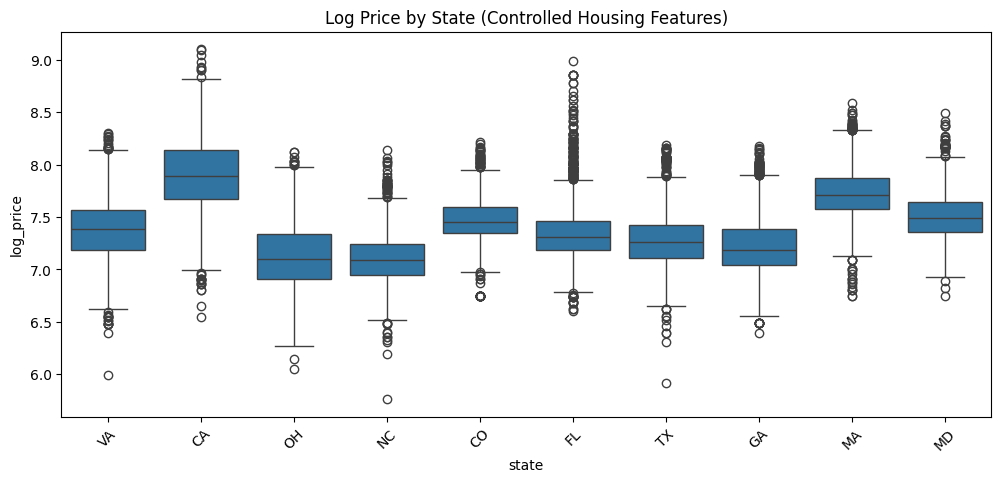

In [49]:
# Choose a "standard room type"
df_control = df[
    (df["square_feet"] >= 1000) &
    (df["square_feet"] <= 1500) &
    (df["bedrooms"] == 2) &
    (df["bathrooms"] >= 1) & (df["bathrooms"] <= 2)
].copy()

print(df_control.shape)

# influence of state
top_states = df_control["state"].value_counts().head(10).index
df_control_state = df_control[df_control["state"].isin(top_states)]

plt.figure(figsize=(12,5))
sns.boxplot(data=df_control_state, x="state", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by State (Controlled Housing Features)")
plt.show()

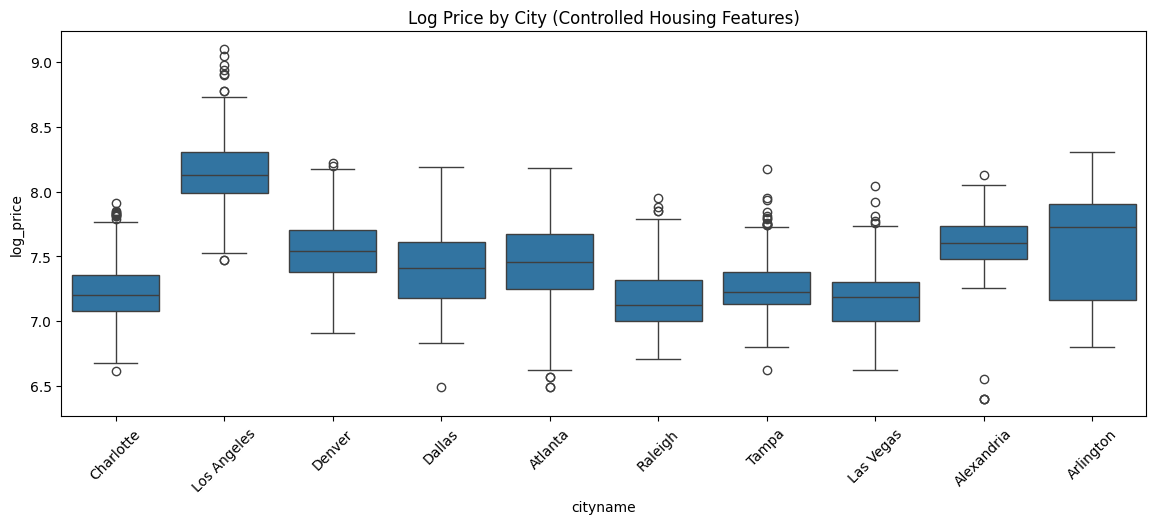

In [50]:
#influence of city
top_cities = df_control["cityname"].value_counts().head(10).index
df_control_city = df_control[df_control["cityname"].isin(top_cities)]

plt.figure(figsize=(14,5))
sns.boxplot(data=df_control_city, x="cityname", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by City (Controlled Housing Features)")
plt.show()

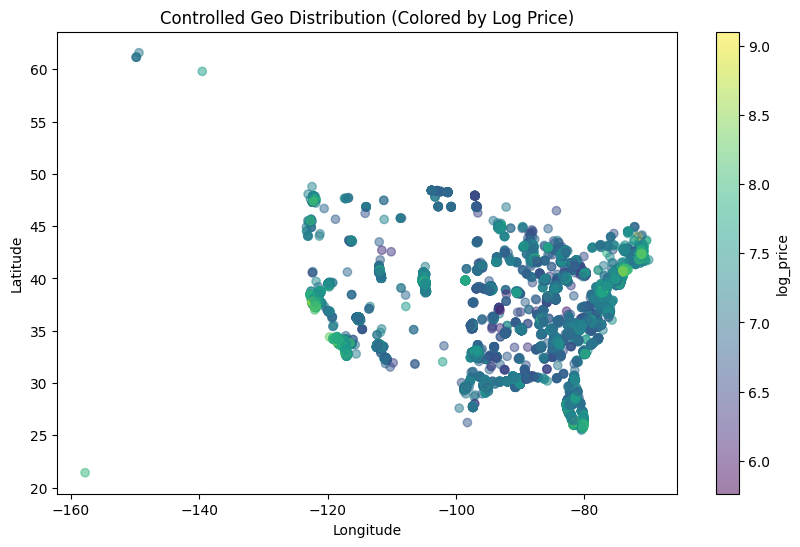

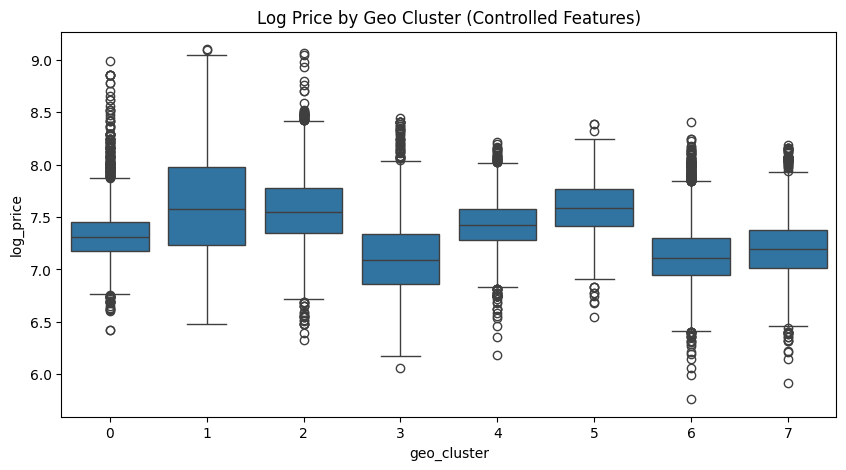

In [52]:
# Viewing longitude and latitude under controlled conditions
plt.figure(figsize=(10,6))
plt.scatter(df_control["longitude"], df_control["latitude"], 
            c=df_control["log_price"], alpha=0.5)
plt.colorbar(label="log_price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Controlled Geo Distribution (Colored by Log Price)")
plt.show()

#geo cluster
from sklearn.cluster import KMeans

df_control = df_control.dropna(subset=["latitude", "longitude"])

kmeans = KMeans(n_clusters=8, random_state=42)
df_control["geo_cluster"] = kmeans.fit_predict(df_control[["latitude", "longitude"]])
plt.figure(figsize=(10,5))
sns.boxplot(x="geo_cluster", y="log_price", data=df_control)
plt.title("Log Price by Geo Cluster (Controlled Features)")
plt.show()

### Geographic Distribution

Listings are concentrated in specific regions, and price levels vary across these regions.  
This indicates that rent is influenced by local market areas rather than continuous coordinates.

### Controlled Analysis

After controlling for housing features (size, bedrooms, bathrooms),  
price differences across locations still remain.  
This suggests that location has an independent effect on rent.

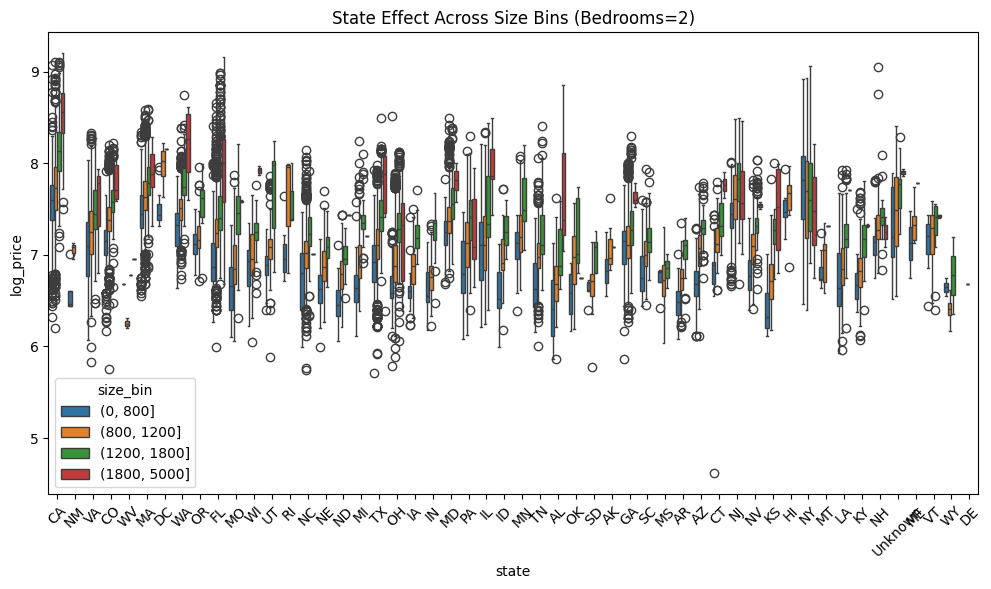

In [53]:
# Binning control
df["size_bin"] = pd.cut(df["square_feet"], bins=[0,800,1200,1800,5000])
df["bed_bin"] = df["bedrooms"]
subset = df[df["bedrooms"] == 2]

plt.figure(figsize=(12,6))
sns.boxplot(x="state", y="log_price", hue="size_bin", data=subset)
plt.xticks(rotation=45)
plt.title("State Effect Across Size Bins (Bedrooms=2)")
plt.show()

### State Effect Across Size Bins

Larger properties tend to have higher prices across all states.  
However, for the same size range, prices still vary significantly by state,  
confirming that geographic factors affect price independently of property size.

Although latitude and longitude do not show strong linear relationships with price, clear spatial clusters exist. After controlling for housing features, location still has a strong effect. Compared to state and city, geographic clustering better captures local market differences.

## EDA conclusion
Although latitude and longitude do not show strong linear relationships with price, the geographic distribution reveals clear spatial clusters. This suggests that rent is not driven by latitude or longitude separately, but by the localized market areas formed by their combination. After controlling for housing features, location still shows a strong effect on price, meaning that geographic differences cannot be explained only by property size or room count. Compared with state and city, geographic clustering provides a more data-driven and flexible way to capture local market differences.

#  First modeling

In [ ]:
# Formal baseline dataset
# Formal baseline dataset
df_baseline = df[["square_feet", "bedrooms", "bathrooms", "state", "log_price"]].dropna().copy()

print(df_baseline.shape)
df_baseline.head()

# Handle categorical variables
df_baseline = pd.get_dummies(df_baseline, columns=["state"], drop_first=True)

#Define X and y
X = df_baseline.drop(columns=["log_price"])
y = df_baseline["log_price"]


(99057, 5)


In [58]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(79245, 54) (19812, 54)


In [59]:
# Train baseline model
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline MAE:", mean_absolute_error(y_test, y_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Baseline MAE: 0.2191879053200354
Baseline RMSE: 0.28766335603794957


### Baseline modeling
A baseline Ridge regression model was built using structural features (`square_feet`, `bedrooms`, `bathrooms`) and state-level location information. The model was trained on 80% of the data and tested on the remaining 20%.

The baseline results show that these variables provide a reasonable first explanation of rental price differences, but prediction errors remain. This suggests that state-level geography may be too coarse to fully capture localized rental market patterns, motivating the next step of using geographic clustering.

In [83]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for k in [10, 20, 30]:
    
    # 1️⃣ Regenerate the cluster (without overwriting other experiments)
    df["geo_cluster"] = KMeans(n_clusters=k, random_state=42)\
                        .fit_predict(df[["latitude", "longitude"]])
    
    # 2️⃣ Build the dataset
    df_cluster = df[[
        "square_feet",
        "bedrooms",
        "bathrooms",
        "geo_cluster",
        "log_price"
    ]].dropna().copy()
    
    df_cluster = pd.get_dummies(df_cluster, columns=["geo_cluster"], drop_first=True)
    
    # 3️⃣ Define X and y
    X_cluster = df_cluster.drop(columns=["log_price"])
    y_cluster = df_cluster["log_price"]
    
    # 4️⃣ Use baseline's index (crucial!)
    X_train_c = X_cluster.loc[X_train.index]
    X_test_c = X_cluster.loc[X_test.index]
    y_train_c = y_cluster.loc[y_train.index]
    y_test_c = y_cluster.loc[y_test.index]
    
    # 5️⃣ Train the model
    model = Ridge(alpha=1.0)
    model.fit(X_train_c, y_train_c)
    
    y_pred = model.predict(X_test_c)
    
    mae = mean_absolute_error(y_test_c, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_c, y_pred))
    
    results.append((k, mae, rmse))

# 6️⃣ Output results
for r in results:
    print(f"k={r[0]} | MAE={r[1]:.4f} | RMSE={r[2]:.4f}")

k=10 | MAE=0.2641 | RMSE=0.3389
k=20 | MAE=0.2279 | RMSE=0.2991
k=30 | MAE=0.2186 | RMSE=0.2893


The results show that the cluster-based models do not significantly outperform the baseline model using state-level information. 

When the number of clusters is small (k=10), the model performs substantially worse, indicating that coarse geographic grouping fails to capture meaningful differences in local rental markets. 

As the number of clusters increases (k=20 and k=30), the performance improves and approaches the baseline. This suggests that finer spatial segmentation better reflects local market conditions. 

However, even with k=30, the cluster model only slightly improves MAE while slightly worsening RMSE, indicating no clear advantage over the state-based representation. 

Overall, this suggests that state-level geographic information already captures a strong portion of rental price variation, and clustering based on latitude and longitude does not provide substantial additional predictive power in this setting.

In [84]:
# =========================
# Combined model: state + geo_cluster
# =========================

from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. Create geo_cluster with k=30
df["geo_cluster_30"] = KMeans(n_clusters=30, random_state=42).fit_predict(
    df[["latitude", "longitude"]]
)

# 2. Build combined dataset
df_combined = df[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "geo_cluster_30",
    "log_price"
]].dropna().copy()

# 3. One-hot encode state and geo_cluster
df_combined = pd.get_dummies(
    df_combined,
    columns=["state", "geo_cluster_30"],
    drop_first=True
)

# 4. Define X and y
X_combined = df_combined.drop(columns=["log_price"])
y_combined = df_combined["log_price"]

# 5. Use the SAME train/test index as baseline
X_combined_train = X_combined.loc[X_train.index]
X_combined_test = X_combined.loc[X_test.index]

y_combined_train = y_combined.loc[y_train.index]
y_combined_test = y_combined.loc[y_test.index]

# 6. Train model
combined_model = Ridge(alpha=1.0)
combined_model.fit(X_combined_train, y_combined_train)

# 7. Predict and evaluate
y_combined_pred = combined_model.predict(X_combined_test)

combined_mae = mean_absolute_error(y_combined_test, y_combined_pred)
combined_rmse = np.sqrt(mean_squared_error(y_combined_test, y_combined_pred))

print("Combined MAE:", combined_mae)
print("Combined RMSE:", combined_rmse)

Combined MAE: 0.2082350952691847
Combined RMSE: 0.27580347993209176


The combined model significantly outperforms both the baseline and cluster-only models. 

This indicates that geographic clusters capture additional local market variation that is not fully explained by state-level information alone. 

While clusters cannot replace traditional geographic variables such as state, they provide complementary information that improves predictive performance when used together.